<a href="https://colab.research.google.com/github/WooSeungJi/WM811K-Project/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_WM_811K_Wafer_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os

os.listdir('/content/drive/MyDrive')

['bugreport-NRD90U-2019-11-14-16-04-22.zip',
 'bugreport-NRD90U-2019-11-14-16-04-22.png',
 'Classroom',
 'Google AI Studio',
 'Colab Notebooks',
 '25-2 반도체공학 Assignment.gdoc',
 '머신러닝 4. Machine Learning Pipeline - 실습.ipynb',
 'ML Project']

In [14]:
import os

print(os.listdir('/content/drive/MyDrive/ML Project'))

['WM811K']


In [18]:
print(os.listdir('/content/drive/MyDrive/ML Project/WM811K'))

['LSWMD.pkl']


In [19]:
import pandas as pd
import numpy as np
import os

file_path = "/content/drive/MyDrive/ML Project/WM811K/LSWMD.pkl"

df = pd.read_pickle(file_path)

print("데이터 로드 완료")
print("데이터 크기:", df.shape)
df.head()

데이터 로드 완료
데이터 크기: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


#**현재 failureType을 보면 [[none]]으로 들어가 있다.**
**그래서 그냥 문자열이 아니라, 안쪽에 들어있는 값을 꺼내야 한다.**


In [20]:
print(df.columns)

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [21]:
# 라벨 추출 진행
# failureType
def get_label(x):
    try:
        return x[0][0]
    except:
        return 'unknown'

df['label'] = df['failureType'].apply(get_label)

print("라벨 종류:")
print(df['label'].unique())

print("\n클래스별 개수:")
print(df['label'].value_counts())

라벨 종류:
[np.str_('none') np.str_('Loc') 'unknown' np.str_('Edge-Loc')
 np.str_('Center') np.str_('Edge-Ring') np.str_('Scratch')
 np.str_('Random') np.str_('Near-full') np.str_('Donut')]

클래스별 개수:
label
unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


#**이를 통해 전체 데이터 중 상당수는 결함 라벨이 없는 데이터임을 알 수 있다.**
여기서 unknown은 내가 직접 만든 라벨이다.


In [22]:
df_labeled = df[df['label'] != 'unknown'].copy()

print("전체 데이터 크기:", df.shape)
print("라벨 있는 데이터 크기:", df_labeled.shape)

print("\n라벨 있는 데이터의 클래스별 개수:")
print(df_labeled['label'].value_counts())

전체 데이터 크기: (811457, 7)
라벨 있는 데이터 크기: (172950, 7)

라벨 있는 데이터의 클래스별 개수:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [23]:
label_count = df_labeled['label'].value_counts()
label_ratio = df_labeled['label'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "count": label_count,
    "ratio(%)": label_ratio.round(2)
})

class_summary

,count,ratio(%)
label,,
none,147431,85.24
Edge-Ring,9680,5.60
Edge-Loc,5189,3.00
Center,4294,2.48
Loc,3593,2.08
Scratch,1193,0.69
Random,866,0.50
Donut,555,0.32
Near-full,149,0.09


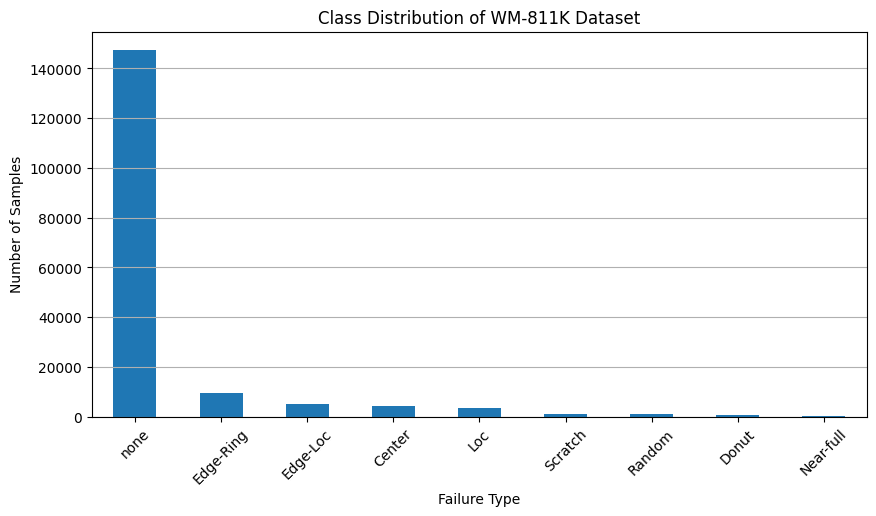

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
label_count.plot(kind='bar')
plt.title("Class Distribution of WM-811K Dataset")
plt.xlabel("Failure Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# **none 클래스가 압도적으로 많다.**
따라서 만약 만들어진 모델이 대부분을 none으로 예측을 하더라도 정확도가 높아 보이는 오류가 발생할 수 있다.
# **클래스 불균형 처리가 필요하다.**